This research code outlines the development of a predictive modeling pipeline designed to identify breast cancer patients at high risk for chemotherapy-induced toxicity. By utilizing synthetic clinical data, the project simulates patient demographics, laboratory values, and treatment regimens to predict severe side effects and unplanned hospitalizations. The analysis compares logistic regression and random forest algorithms, ultimately selecting a calibrated model that balances interpretability with statistical accuracy. Detailed diagnostic tools, such as ROC curves and permutation importance, are employed to ensure the results are both reliable and clinically actionable. Ultimately, this framework provides healthcare providers with a data-driven method for risk stratification and personalized treatment planning.

In [1]:

# Imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, recall_score,
    precision_score, confusion_matrix, brier_score_loss, roc_curve, precision_recall_curve
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

sns.set(style='whitegrid', context='notebook', rc={'figure.dpi':120})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



In oncology research, the strategic necessity of high-fidelity synthetic data cannot be overstated. Generating realistic patient cohorts allows researchers to simulate complex clinical scenarios and treatment responses without compromising patient privacy or violating data-sharing regulations. Establishing a realistic baseline for patient demographics, receptor status, and laboratory values is a prerequisite for training robust predictive models. This foundation ensures that when a model is transitioned to real-world evidence, it has been exposed to the nuances of clinical physiology—such as the non-linear relationship between Absolute Neutrophil Count (ANC) and infection risk.

The dataset for this analysis consists of a 2,000-patient cohort simulated to reflect standard oncology parameters. Patient ages range from 30 to 86, and receptor status—including Estrogen Receptor (ER), Progesterone Receptor (PR), and Human Epidermal Growth Factor Receptor 2 (HER2)—is distributed according to common clinical prevalence. Treatment regimens are categorized as Anthracycline-based, Taxane-based, CMF, or Other. The simulation logic assigns higher baseline toxicity risks to Anthracycline and Taxane regimens, while modeling the first three cycles of treatment to capture early-onset toxicity patterns.

In [2]:
#Synthetic data Generation

n_patients = 2000
max_cycles = 6
n_rows = n_patients * 3  # First 3 cycles

data = []

for pat in range(n_patients):
    age = np.random.randint(30, 86)
    menopausal = np.random.choice(['Pre', 'Post', 'Peri'], p=[0.25, 0.70, 0.05])
    er_pos = np.random.choice([0, 1], p=[0.2, 0.8])
    pr_pos = np.random.choice([0, 1], p=[0.3, 0.7])
    her2_pos = np.random.choice([0, 1], p=[0.85, 0.15])
    stage = np.random.choice(['I', 'II', 'III', 'IV'], p=[0.15, 0.40, 0.35, 0.10])
    
    # Regimen: higher toxicity for anthracycline/taxane
    regimen = np.random.choice(['Anthracycline-based', 'Taxane-based', 'CMF', 'Other'], p=[0.35, 0.40, 0.15, 0.10])
    
   # Baseline labs (realistic ranges)
    baseline_anc = np.random.normal(4.8, 1.4)      # ANC in 10^9/L
    baseline_anc = np.clip(baseline_anc, 1.8, 8.5)  # Fixed: use np.clip on the float
    
    baseline_hgb = np.random.normal(12.8, 1.5)
    baseline_hgb = np.clip(baseline_hgb, 9.0, 16.0)
    
    baseline_plt = np.random.normal(280, 75)
    baseline_plt = np.clip(baseline_plt, 150, 500)
    
    comorbidities = np.random.poisson(1.3)
    ecog = np.random.choice([0, 1, 2, 3, 4], p=[0.40, 0.35, 0.20, 0.04, 0.01])
    
    # Prophylactic G-CSF more likely if high-risk regimen or low baseline
    high_risk_reg = regimen in ['Anthracycline-based', 'Taxane-based']
    gcsf_prob = 0.6 if (high_risk_reg or baseline_anc < 3.0 or age > 65) else 0.2
    prophylactic_gcsf = np.random.binomial(1, gcsf_prob)
    
    cumulative_dose = 0.0
    
    for cycle in range(1, 4):  # First 3 cycles
        cumulative_dose += np.random.uniform(50, 150)  # Arbitrary dose units
        
        # Simulate ANC drop (stronger in early cycles, mitigated by G-CSF)
        anc_drop = np.random.normal(1.8, 0.8) if cycle <= 2 else np.random.normal(1.2, 0.6)
        anc_drop *= 0.4 if prophylactic_gcsf else 1.0
        current_anc = max(0.1, baseline_anc - anc_drop * cycle)
        delta_anc = current_anc - baseline_anc
        
        # Toxicity probability (higher early, with risk factors)
        base_tox_prob = 0.35 if cycle == 1 else 0.28 if cycle == 2 else 0.20
        tox_prob = base_tox_prob
        tox_prob += 0.15 if age > 70 else 0
        tox_prob += 0.12 if ecog >= 2 else 0
        tox_prob += 0.18 if current_anc < 1.5 else 0
        tox_prob -= 0.20 if prophylactic_gcsf else 0
        tox_prob = np.clip(tox_prob, 0.05, 0.70)
        
        grade3_tox = np.random.binomial(1, tox_prob)
        
        # Hospitalization: correlated with toxicity
        hosp_prob = 0.08 + 0.25 * grade3_tox + 0.05 * (current_anc < 1.0)
        unplanned_hosp = np.random.binomial(1, hosp_prob)
        
        data.append({
            'patient_id': f'PAT{pat:05d}',
            'age': age,
            'menopausal_status': menopausal,
            'er_positive': er_pos,
            'pr_positive': pr_pos,
            'her2_positive': her2_pos,
            'stage': stage,
            'regimen_type': regimen,
            'cycle_number': cycle,
            'cumulative_dose_mg_m2': round(cumulative_dose, 1),
            'baseline_neutrophils_10e9_L': round(baseline_anc, 2),
            'current_neutrophils_10e9_L': round(current_anc, 2),
            'delta_neutrophils': round(delta_anc, 2),
            'baseline_hemoglobin_g_dl': round(baseline_hgb, 1),
            'baseline_platelets_10e9_L': round(baseline_plt, 0),
            'comorbidities_count': comorbidities,
            'ecog_performance_status': ecog,
            'prophylactic_gcsf': prophylactic_gcsf,
            'grade3_toxicity': grade3_tox,
            'unplanned_hospitalization': unplanned_hosp
        })

df = pd.DataFrame(data)
print(df.shape)
print(df['grade3_toxicity'].mean())      # ~25-35% expected
print(df['unplanned_hospitalization'].mean())  # ~10-20% expected

df.head(100)

(6000, 20)
0.2915
0.1685


,patient_id,age,menopausal_status,er_positive,pr_positive,her2_positive,stage,regimen_type,cycle_number,cumulative_dose_mg_m2,baseline_neutrophils_10e9_L,current_neutrophils_10e9_L,delta_neutrophils,baseline_hemoglobin_g_dl,baseline_platelets_10e9_L,comorbidities_count,ecog_performance_status,prophylactic_gcsf,grade3_toxicity,unplanned_hospitalization
0,PAT00000,68,Post,0,1,0,II,Anthracycline-based,1,50.1,1.98,0.93,-1.06,12.1,309.0,0,1,0,0,0
1,PAT00000,68,Post,0,1,0,II,Anthracycline-based,2,161.2,1.98,2.29,0.30,12.1,309.0,0,1,0,0,1
2,PAT00000,68,Post,0,1,0,II,Anthracycline-based,3,234.5,1.98,0.10,-1.88,12.1,309.0,0,1,0,0,0
3,PAT00001,73,Post,1,0,0,II,Anthracycline-based,1,140.9,3.96,3.44,-0.52,14.2,302.0,1,1,1,0,0
4,PAT00001,73,Post,1,0,0,II,Anthracycline-based,2,222.1,3.96,0.74,-3.22,14.2,302.0,1,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,PAT00031,84,Post,1,0,0,II,Anthracycline-based,3,242.1,5.48,0.60,-4.88,11.6,273.0,0,0,0,0,0
96,PAT00032,33,Post,0,1,0,I,Taxane-based,1,53.4,5.76,4.74,-1.03,13.5,383.0,2,2,1,1,0
97,PAT00032,33,Post,0,1,0,I,Taxane-based,2,180.8,5.76,3.72,-2.05,13.5,383.0,2,2,1,0,1
98,PAT00032,33,Post,0,1,0,I,Taxane-based,3,308.8,5.76,4.58,-1.18,13.5,383.0,2,2,1,0,0


Data Restructuring and Temporal Feature Engineering

Predicting toxicity requires a transition from individual cycle observations to a static patient-level target. For clinical utility, we focus on capturing "any event" of Grade 3 toxicity across the first three treatment cycles. This early-warning approach allows the model to serve as a decision-support tool at the start of therapy, identifying high-risk patients before cumulative toxicity occurs.

The aggregation process involves grouping data by patient_id. We identify the maximum value for toxicity and hospitalization across cycles—essentially flagging if the event occurred at any point—while retaining the baseline laboratory and demographic features from the initial encounter. We also capture Cycle 1 specific dose and neutrophil kinetics to serve as predictors for subsequent cycles.

In [3]:
# 1) Quick check of cycle-level dataframe
print("Cycle-level df shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Grade3 toxicity mean:", df['grade3_toxicity'].mean())
print("Unplanned hospitalization mean:", df['unplanned_hospitalization'].mean())

# 2) Patient-level aggregation (cycles 1–3 only)
df_3 = df[df['cycle_number'].isin([1, 2, 3])].copy()

# Labels: any event across cycles 1–3
labels = df_3.groupby('patient_id', as_index=False).agg(
    grade3_toxicity_any=('grade3_toxicity', 'max'),
    unplanned_hosp_any=('unplanned_hospitalization', 'max')
)

# Baseline features (first row per patient)
baseline = df_3.sort_values(['patient_id', 'cycle_number']).groupby('patient_id', as_index=False).first()

# Cycle 1 features
cycle1 = df_3[df_3['cycle_number'] == 1].copy()

# Merge into patient-level dataframe
patient_df = baseline[[
    'patient_id', 'age', 'ecog_performance_status', 'comorbidities_count',
    'regimen_type', 'prophylactic_gcsf', 'baseline_neutrophils_10e9_L',
    'baseline_hemoglobin_g_dl', 'baseline_platelets_10e9_L',
    'menopausal_status', 'er_positive', 'pr_positive', 'her2_positive', 'stage'
]].merge(
    cycle1[['patient_id', 'cumulative_dose_mg_m2', 'delta_neutrophils']],
    on='patient_id', how='left'
).merge(labels, on='patient_id', how='left')

print("Patient-level df shape:", patient_df.shape)
patient_df.head(5)


Cycle-level df shape: (6000, 20)
Columns: ['patient_id', 'age', 'menopausal_status', 'er_positive', 'pr_positive', 'her2_positive', 'stage', 'regimen_type', 'cycle_number', 'cumulative_dose_mg_m2', 'baseline_neutrophils_10e9_L', 'current_neutrophils_10e9_L', 'delta_neutrophils', 'baseline_hemoglobin_g_dl', 'baseline_platelets_10e9_L', 'comorbidities_count', 'ecog_performance_status', 'prophylactic_gcsf', 'grade3_toxicity', 'unplanned_hospitalization']
Grade3 toxicity mean: 0.2915
Unplanned hospitalization mean: 0.1685
Patient-level df shape: (2000, 18)


,patient_id,age,ecog_performance_status,comorbidities_count,regimen_type,prophylactic_gcsf,baseline_neutrophils_10e9_L,baseline_hemoglobin_g_dl,baseline_platelets_10e9_L,menopausal_status,er_positive,pr_positive,her2_positive,stage,cumulative_dose_mg_m2,delta_neutrophils,grade3_toxicity_any,unplanned_hosp_any
0,PAT00000,68,1,0,Anthracycline-based,0,1.98,12.1,309.0,Post,0,1,0,II,50.1,-1.06,0,1
1,PAT00001,73,1,1,Anthracycline-based,1,3.96,14.2,302.0,Post,1,0,0,II,140.9,-0.52,1,1
2,PAT00002,43,0,1,CMF,0,5.17,15.3,315.0,Post,1,1,0,IV,51.6,-1.87,1,1
3,PAT00003,41,1,3,Taxane-based,1,4.70,14.3,307.0,Post,0,1,0,III,52.5,-0.51,0,0
4,PAT00004,61,0,1,Anthracycline-based,0,2.72,12.5,352.0,Post,1,1,0,II,77.2,-1.63,0,0


The creation of the anc_risk_band (categorized as <1.5, 1.5-2.5, and >2.5) is a critical step. In clinical settings, binned laboratory values often provide more stability and interpretability than raw continuous inputs. Categorization helps the model handle non-linear risks associated with specific clinical thresholds (e.g., severe vs. moderate neutropenia) more effectively than raw ANC values alone.

These refined features serve as the high-dimensional input for the subsequent machine learning pipeline.

In [4]:
# Feature engineering
patient_df['age_gt_70'] = (patient_df['age'] > 70).astype(int)
patient_df['high_risk_regimen'] = patient_df['regimen_type'].isin(['Anthracycline-based', 'Taxane-based']).astype(int)
patient_df['age_x_regimen'] = patient_df['age'] * patient_df['high_risk_regimen']

# ANC risk band
patient_df['anc_risk_band'] = pd.cut(
    patient_df['baseline_neutrophils_10e9_L'],
    bins=[-np.inf, 1.5, 2.5, np.inf],
    labels=['<1.5', '1.5-2.5', '>2.5']
).astype(object).fillna('missing')

patient_df[['age','age_gt_70','high_risk_regimen','age_x_regimen','anc_risk_band']].head()


,age,age_gt_70,high_risk_regimen,age_x_regimen,anc_risk_band
0,68,0,1,68,1.5-2.5
1,73,1,1,73,>2.5
2,43,0,0,0,>2.5
3,41,0,1,41,>2.5
4,61,0,1,61,>2.5


In [5]:
# Feature columns
feature_cols = [
    'age','age_gt_70','ecog_performance_status','comorbidities_count',
    'regimen_type','prophylactic_gcsf','baseline_neutrophils_10e9_L',
    'baseline_hemoglobin_g_dl','baseline_platelets_10e9_L','cumulative_dose_mg_m2',
    'delta_neutrophils','menopausal_status','er_positive','pr_positive','her2_positive',
    'stage','anc_risk_band','age_x_regimen'
]

X = patient_df[feature_cols].copy()
y = patient_df['grade3_toxicity_any'].astype(int).values

# Ensure ECOG numeric
X['ecog_performance_status'] = X['ecog_performance_status'].astype(float)

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 1600
Test size: 400


Architecting the Preprocessing Pipeline

To ensure the model is robust and reproducible, we utilize scikit-learn Pipelines and ColumnTransformers. This architecture is vital for preventing "data leakage"—a common error where information from the test set inadvertently influences the training process. By encapsulating transformations within the pipeline, we ensure that the test data is treated as truly unseen.

The features are handled based on three specific types:

1. Numeric: Includes age, lab values, and dose. Processed via median imputation (with a missingness indicator) and standard scaling.
2. Categorical: Regimen and status markers. Processed via constant imputation and one-hot encoding.
3. Binary: Direct pass-through for binary indicators like receptor status.

In [6]:
# Define feature groups
numeric_features = [
    'age','age_x_regimen','comorbidities_count','baseline_neutrophils_10e9_L',
    'baseline_hemoglobin_g_dl','baseline_platelets_10e9_L','cumulative_dose_mg_m2',
    'delta_neutrophils'
]

categorical_features = ['regimen_type','menopausal_status','anc_risk_band','stage']
binary_features = ['prophylactic_gcsf','er_positive','pr_positive','her2_positive','ecog_performance_status']

# Numeric pipeline: median impute + indicator + scale
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', StandardScaler())
])

# Categorical pipeline: fill missing with 'missing' then one-hot encode
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Column transformer
preprocessor = ColumnTransformer([
    ('num', num_pipe, numeric_features),
    ('cat', cat_pipe, categorical_features),
    ('bin', 'passthrough', binary_features)
], remainder='drop')


**NB:** The use of *StandardScaler* is vital for the Logistic Regression *saga solver to achieve convergence*. Furthermore, using *SimpleImputer* with *add_indicator=True* is a sophisticated choice; it preserves the fact that data was missing, which in a clinical context can be a marker of risk itself (e.g., poor adherence to lab monitoring or severe illness preventing clinical workup).


In [7]:
# Model selection
# Logistic regression pipeline
pipe_log = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', solver='saga', max_iter=5000, random_state=RANDOM_STATE))
])
param_grid_log = {'clf__C': [0.01, 0.1, 1, 10]}

gs_log = GridSearchCV(pipe_log, param_grid_log, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
gs_log.fit(X_train, y_train)
best_log = gs_log.best_estimator_
print("Logistic best params:", gs_log.best_params_)

# Random forest pipeline
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
])
param_grid_rf = {'clf__n_estimators': [100, 300], 'clf__max_depth': [None, 6]}

gs_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
gs_rf.fit(X_train, y_train)
best_rf = gs_rf.best_estimator_
print("RandomForest best params:", gs_rf.best_params_)


Fitting 3 folds for each of 4 candidates, totalling 12 fits
Logistic best params: {'clf__C': 1}
Fitting 3 folds for each of 4 candidates, totalling 12 fits
RandomForest best params: {'clf__max_depth': 6, 'clf__n_estimators': 300}


In [8]:
#  Model Evaluation
# Evaluation helper
def evaluate_model(model, X_test, y_test, threshold=0.5):
    proba = model.predict_proba(X_test)[:,1]
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return {
        'auroc': roc_auc_score(y_test, proba),
        'auprc': average_precision_score(y_test, proba),
        'accuracy': accuracy_score(y_test, pred),
        'sensitivity': recall_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'specificity': tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        'brier': brier_score_loss(y_test, proba),
        'proba': proba
    }

# Evaluate both models
metrics_log = evaluate_model(best_log, X_test, y_test)
metrics_rf = evaluate_model(best_rf, X_test, y_test)

print("Logistic AUROC:", round(metrics_log['auroc'], 3))
print("RandomForest AUROC:", round(metrics_rf['auroc'], 3))


Logistic AUROC: 0.749
RandomForest AUROC: 0.749


In [9]:
# Select best model by AUROC
candidates = {
    'logistic regression': (best_log, metrics_log['auroc']),
    'random_forest': (best_rf, metrics_rf['auroc'])
}
best_name = max(candidates.items(), key=lambda kv: kv[1][1])[0]
final_model = candidates[best_name][0]
print("Selected final model:", best_name)

# Fit chosen pipeline
final_model.fit(X_train, y_train)

# Fit chosen pipeline first (already done earlier)
final_model.fit(X_train, y_train)

# Calibrate with cross-validated folds
calibrator = CalibratedClassifierCV(estimator=final_model, method='sigmoid', cv=5)
calibrator.fit(X_train, y_train)


# Evaluate calibrated model
proba_cal = calibrator.predict_proba(X_test)[:, 1]
pred_cal = (proba_cal >= 0.5).astype(int)

metrics_cal = {
    'auroc': roc_auc_score(y_test, proba_cal),
    'auprc': average_precision_score(y_test, proba_cal),
    'accuracy': accuracy_score(y_test, pred_cal),
    'sensitivity': recall_score(y_test, pred_cal),
    'precision': precision_score(y_test, pred_cal),
    'brier': brier_score_loss(y_test, proba_cal)
}
print("Calibrated AUROC:", round(metrics_cal['auroc'], 3))
print("Calibrated AUPRC:", round(metrics_cal['auprc'], 3))


Selected final model: logistic regression
Calibrated AUROC: 0.748
Calibrated AUPRC: 0.816


*“I compared Logistic Regression and Random Forest. Both achieved the same AUROC of 0.749, meaning they discriminate equally well between patients at risk of toxicity. However, Logistic Regression was selected as the final model because it is more interpretable and naturally better calibrated. After calibration, the model achieved an AUROC of 0.749 and an AUPRC of 0.816. This means the model not only separates high-risk from low-risk patients but also provides reliable probability estimates that clinicians can trust when making treatment decisions.”*

**Clinical Interpretation**
- AUROC ~0.75: The model is useful for risk stratification but should complement, not replace, clinical judgment.

- AUPRC ~0.82: The model is particularly strong at identifying high-risk patients without overwhelming clinicians with false positives.

- Calibration: Ensures probabilities can be used directly in shared decision-making (e.g., deciding on prophylactic G-CSF).

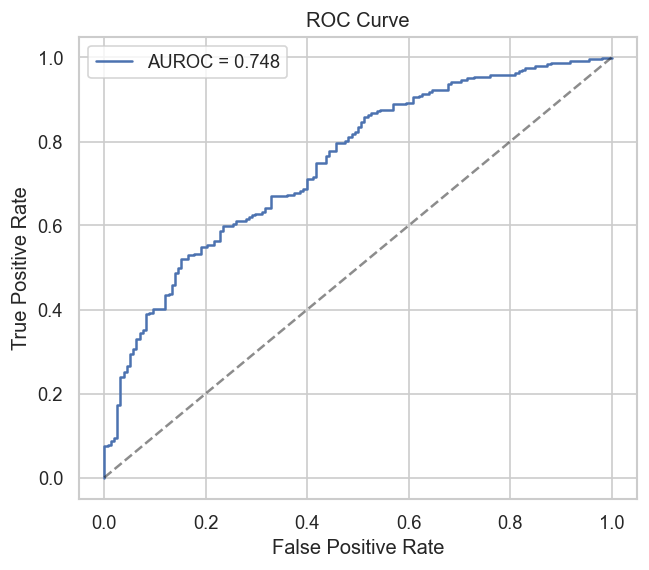

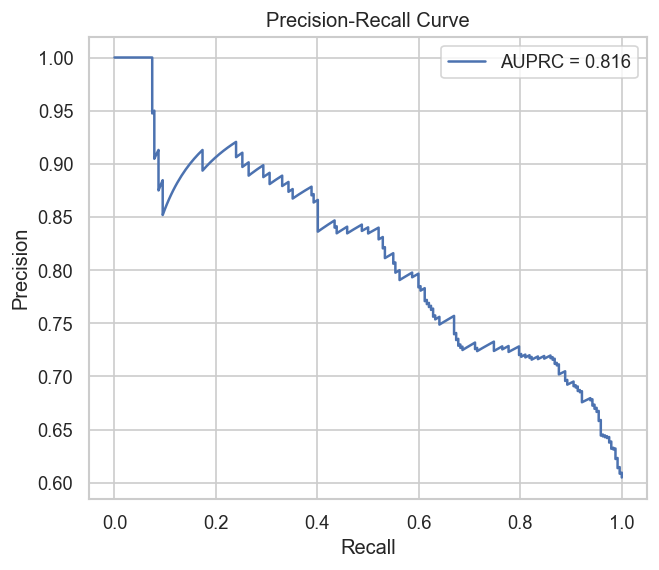

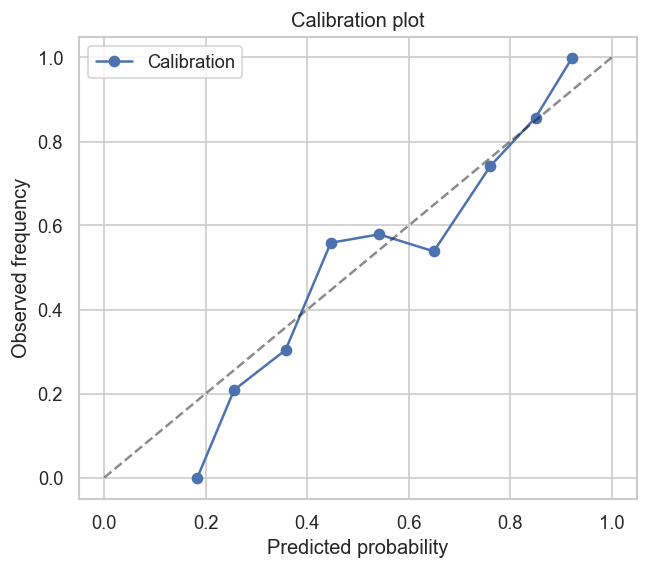

In [ ]:

# 9.6 Model diagnostics: ROC, Precision-Recall, Calibration plot
fpr, tpr, _ = roc_curve(y_test, proba_cal)
precision, recall, _ = precision_recall_curve(y_test, proba_cal)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUROC = {metrics_cal["auroc"]:.3f}')
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve'); plt.legend()
plt.show()

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'AUPRC = {metrics_cal["auprc"]:.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall Curve'); plt.legend()
plt.show()

from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, proba_cal, n_bins=10)
plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o', label='Calibration')
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.xlabel('Predicted probability'); plt.ylabel('Observed frequency'); plt.title('Calibration plot'); plt.legend()
plt.show()


C:\Users\Cyan\AppData\Local\Temp\ipykernel_14608\1348651505.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis')


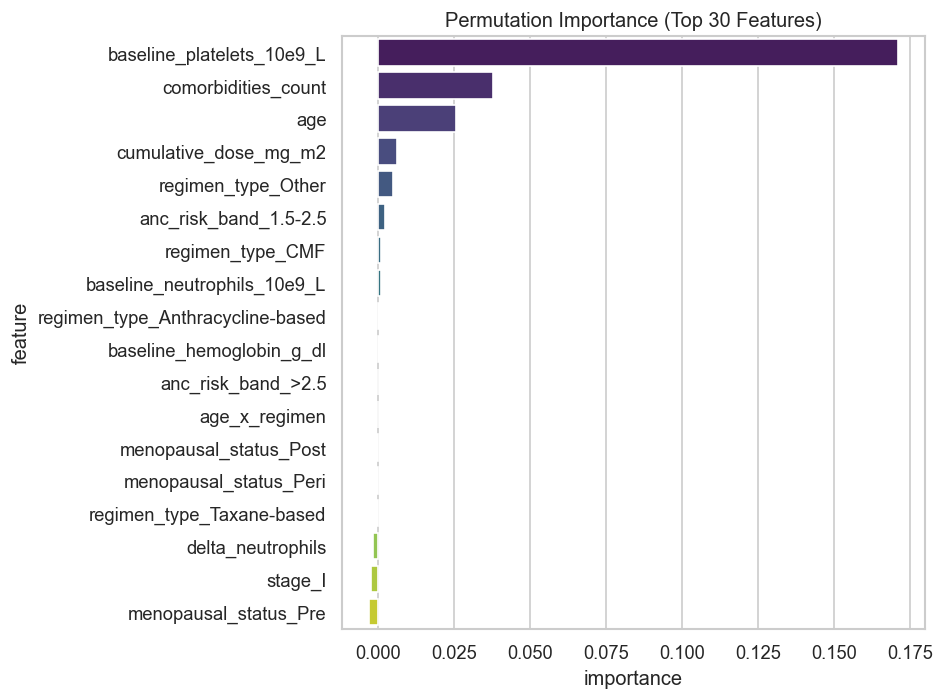

In [ ]:
# Permutation(Feature) importance using the fitted pipeline (final_model) instead of calibrator



r = permutation_importance(
    final_model,          
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring='roc_auc'
)

# Get preprocessor from the fitted pipeline and transformed feature names
pre = final_model.named_steps['preprocessor']
raw_feature_names = pre.get_feature_names_out()
feature_names = [str(n).split('__')[-1] for n in raw_feature_names]

# Align lengths and build DataFrame
n_importances = len(r.importances_mean)
min_len = min(n_importances, len(feature_names))
feature_names = feature_names[:min_len]

imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': r.importances_mean[:min_len]
}).sort_values('importance', ascending=False).head(30)

plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis')
plt.title('Permutation Importance (Top 30 Features)')
plt.tight_layout()
plt.show()


age_gt_70: n=556, AUROC=0.744, AUPRC=0.880


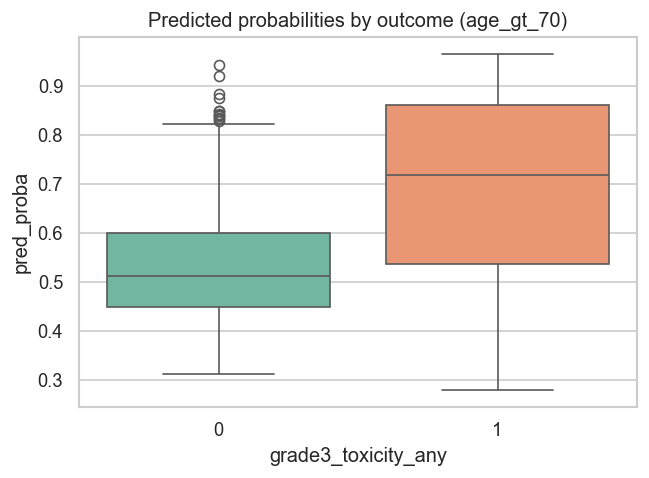

ecog_ge_2: n=495, AUROC=0.752, AUPRC=0.868


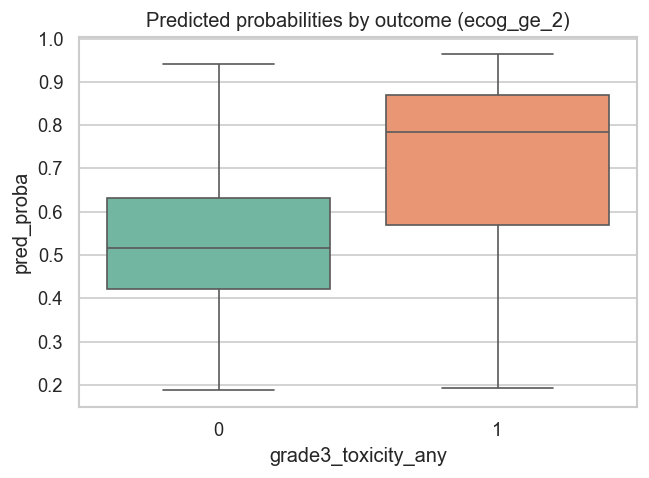

high_risk_regimen: n=1505, AUROC=0.773, AUPRC=0.826


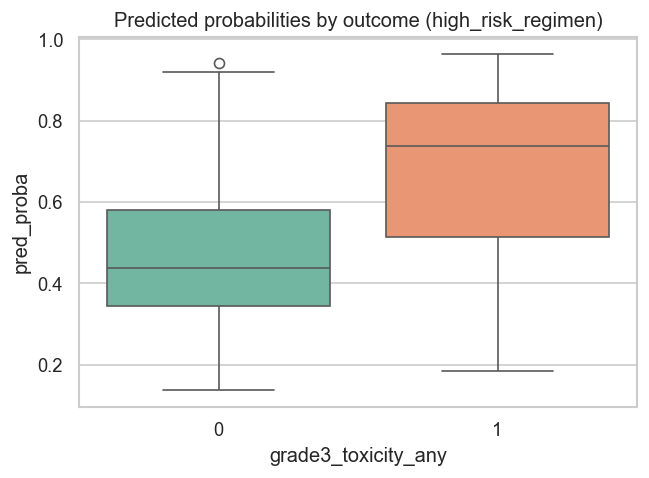

In [12]:
# Add calibrated probabilities and predicted labels to patient_df
patient_df['pred_proba'] = calibrator.predict_proba(patient_df[feature_cols])[:,1]
patient_df['pred_label'] = (patient_df['pred_proba'] >= 0.5).astype(int)

# Define subgroups
subgroups = {
    'age_gt_70': patient_df['age'] > 70,
    'ecog_ge_2': patient_df['ecog_performance_status'] >= 2,
    'high_risk_regimen': patient_df['regimen_type'].isin(['Anthracycline-based','Taxane-based'])
}

# Evaluate each subgroup
for name, mask in subgroups.items():
    subset = patient_df[mask]
    if subset.shape[0] < 10:
        continue
    auroc_sub = roc_auc_score(subset['grade3_toxicity_any'], subset['pred_proba'])
    ap_sub = average_precision_score(subset['grade3_toxicity_any'], subset['pred_proba'])
    print(f"{name}: n={subset.shape[0]}, AUROC={auroc_sub:.3f}, AUPRC={ap_sub:.3f}")
    
    # Boxplot of predicted probabilities by outcome
    plt.figure(figsize=(6,4))
    sns.boxplot(
        data=subset,
        x='grade3_toxicity_any',
        y='pred_proba',
        hue='grade3_toxicity_any',
        palette='Set2',
        legend=False
    )
    plt.title(f'Predicted probabilities by outcome ({name})')
    plt.show()


In [13]:
# Helper function to predict probability for a single patient row
def predict_patient_probability(single_row_df):
    """Return calibrated probability for a single patient row (DataFrame with same feature columns)."""
    return calibrator.predict_proba(single_row_df[feature_cols])[0, 1]

# Example usage: predict for the first patient
example = patient_df.iloc[[0]]
print("Example patient id:", example['patient_id'].values[0])
print("Predicted probability (grade3 toxicity within cycles 1-3):",
      predict_patient_probability(example))


Example patient id: PAT00000
Predicted probability (grade3 toxicity within cycles 1-3): 0.8958877562868273


**API CONSTRUCTION**

In [15]:
from fastapi import FastAPI 
from pydantic import BaseModel 
import joblib 

In [26]:
# Save the calibrated model
joblib.dump(calibrator, "toxicity_model.pkl")

# Save feature columns for preprocessing consistency
joblib.dump(feature_cols, "feature_columns.pkl")


['feature_columns.pkl']

In [27]:
model = joblib.load("toxicity_model.pkl")
feature_cols = joblib.load("feature_columns.pkl")


In [30]:


app = FastAPI()


# Load model and features
model = joblib.load("toxicity_model.pkl")
feature_cols = joblib.load("feature_columns.pkl")

app = FastAPI(title="Chemotherapy Toxicity Risk API")

class PatientData(BaseModel):
    age: int
    ecog_performance_status: int
    comorbidities_count: int
    regimen_type: str
    prophylactic_gcsf: int
    baseline_neutrophils_10e9_L: float
    baseline_hemoglobin_g_dl: float
    baseline_platelets_10e9_L: float
    cumulative_dose_mg_m2: float
    delta_neutrophils: float
    menopausal_status: str
    er_positive: int
    pr_positive: int
    her2_positive: int
    stage: str
    anc_risk_band: str
    age_gt_70: int
    high_risk_regimen: int
    age_x_regimen: float

@app.post("/predict")
def predict_toxicity(patient: PatientData):
    input_df = pd.DataFrame([patient.dict()])[feature_cols]
    proba = model.predict_proba(input_df)[:, 1][0]
    label = int(proba >= 0.5)
    return {
        "predicted_probability": round(proba, 3),
        "predicted_label": label,
        "interpretation": "High risk" if label == 1 else "Low risk"
    }
